## Imports

In [2]:
%load_ext autoreload
%autoreload 2

from ageing_packages.SR_models import SR_sim, SR_plotting
from ageing_packages.utils import sr_utils as utils
from ageing_packages.hetero_analysis import correlation_analysis as ca
from ageing_packages.hetero_analysis import twin_analysis as ta
from ageing_packages.hetero_analysis import survival_analysis as sa
from ageing_packages.hetero_analysis import hetero_plotting as hp
from ageing_packages.mortality_data_analysis import HMD
from ageing_packages.mortality_models.gamma_gompertz import GammaGompertz as gg
from ageing_packages.hetero_analysis import nhanes_analysis as nhanes
# Fit a Generalized Additive Model (GAM) to the interpolated progeria data
from pygam import LinearGAM, s


import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pickle

def remove_top_right_spines(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.get_xaxis().tick_bottom()            
    ax.get_yaxis().tick_left()
# Apply this to all future plots
plt.rc('axes', facecolor='white')
plt.rc('axes.spines', top=False, right=False)
plt.rc('axes', grid=False)

# Make tick sizes and labels 1.5 times bigger
plt.rc('xtick', labelsize=12)  # Default is 8, so 12 is 1.5x bigger
plt.rc('ytick', labelsize=12)  # Default is 8, so 12 is 1.5x bigger
plt.rc('xtick.major', size=6)  # Default is 4, so 6 is 1.5x bigger
plt.rc('ytick.major', size=6)  # Default is 4, so 6 is 1.5x bigger
plt.rc('xtick.minor', size=3)  # Default is 2, so 3 is 1.5x bigger
plt.rc('ytick.minor', size=3)  # Default is 2, so 3 is 1.5x bigger
plt.rc('xtick.major', width=1.5)  # Default is 1, so 1.5 is 1.5x bigger
plt.rc('ytick.major', width=1.5)  # Default is 1, so 1.5 is 1.5x bigger

# Configure plotly defaults
pio.templates.default = "plotly_white"
pio.templates["plotly_white"].layout.update(
    paper_bgcolor='white',
    plot_bgcolor='white',
    xaxis=dict(
        showline=True,
        linewidth=1,
        linecolor='black',
        mirror=False,
        ticks='outside',
        tickwidth=1,
        tickcolor='black'
    ),
    yaxis=dict(
        showline=True,
        linewidth=1,
        linecolor='black',
        mirror=False,
        ticks='outside',
        tickwidth=1,
        tickcolor='black'
    )
)

import pingouin as pg
import pandas as pd
from scipy import interpolate
from scipy.stats import gaussian_kde, gennorm, norm, gamma, beta
import seaborn as sns
import matplotlib.cm as cm
import sys, os, importlib, warnings, pickle
from scipy.stats import pearsonr
from lifelines import KaplanMeierFitter
import thresholds_functions as th


Loaded exposure group results from /Users/benshenhar/Library/CloudStorage/GoogleDrive-benshenhar@gmail.com/My Drive/Weizmann/Alon Lab/Aging/python/notebooks/thresholds, noise/saved_results/exposure_groups_results.pkl


## Param Variation Changes

In [ ]:
dict = utils.load_baseline_human_params_dict()
dict['Xc'] = 0.97*dict['Xc']
dict['epsilon'] = 1.05*dict['epsilon']
dict['eta'] = 0.96*dict['eta']

th.run_parameter_study(study_type = 'variation' , name = 'usa_2019', baseline_dict = dict)

Processing parameter: eta
  Std: 0.00 completed
  Std: 0.01 completed
  Std: 0.02 completed
  Std: 0.03 completed
  Std: 0.04 completed
  Std: 0.05 completed
  Std: 0.06 completed
  Std: 0.07 completed
  Std: 0.08 completed
  Std: 0.09 completed
  Std: 0.10 completed
  Std: 0.11 completed
  Std: 0.12 completed
  Std: 0.13 completed
  Std: 0.14 completed
  Std: 0.15 completed
  Std: 0.16 completed
  Std: 0.17 completed
  Std: 0.18 completed
  Std: 0.19 completed
  Std: 0.20 completed
Processing parameter: beta
  Std: 0.00 completed
  Std: 0.01 completed
  Std: 0.02 completed
  Std: 0.03 completed
  Std: 0.04 completed
  Std: 0.05 completed
  Std: 0.06 completed
  Std: 0.07 completed
  Std: 0.08 completed
  Std: 0.09 completed
  Std: 0.10 completed
  Std: 0.11 completed
  Std: 0.12 completed
  Std: 0.13 completed
  Std: 0.14 completed
  Std: 0.15 completed
  Std: 0.16 completed
  Std: 0.17 completed
  Std: 0.18 completed
  Std: 0.19 completed
  Std: 0.20 completed
Processing parameter: e

{'baseline': {0: {'steepness_iqr_relative': 7.398656417768416,
   'steepness_iqr_absolute': 7.398656417768416,
   'steepness_cv_relative': 9.37512035850516,
   'steepness_cv_absolute': 9.37512035850516,
   't_median_relative': 84.76027696793004,
   't_median_absolute': 84.76027696793004,
   't_max': 107.56250000000001},
  15: {'steepness_iqr_relative': 6.089347264742924,
   'steepness_iqr_absolute': 7.398690708097322,
   'steepness_cv_relative': 7.6976869480612065,
   'steepness_cv_absolute': 9.376087845188357,
   't_median_relative': 69.76031341107871,
   't_median_absolute': 84.76031341107871,
   't_max': 107.56250125000001},
  20: {'steepness_iqr_relative': 5.652899450291457,
   'steepness_iqr_absolute': 7.398690708097322,
   'steepness_cv_relative': 7.138219982352157,
   'steepness_cv_absolute': 9.376087845188357,
   't_median_relative': 64.76031341107871,
   't_median_absolute': 84.76031341107871,
   't_max': 107.56250125000001},
  30: {'steepness_iqr_relative': 4.780190064836212,

In [ ]:
# Load baseline parameters and setup
base_dict = utils.load_baseline_human_params_dict()
n = int(2e5)
from_t_values = [0, 15, 20, 40, 50]

# Helper function to prepare parameter dictionary
def prepare_params_dict(base_dict, n, param=None, factor=1.0):
    """Prepare parameter dictionary with proper array expansion."""
    dict_copy = base_dict.copy()
    for key in dict_copy.keys():
        if isinstance(dict_copy[key], (np.ndarray, list)) and len(dict_copy[key]) == 1:
            dict_copy[key] = np.repeat(dict_copy[key], n)
        elif np.isscalar(dict_copy[key]):
            dict_copy[key] = np.repeat(np.array([dict_copy[key]]), n)
    
    if param:
        dict_copy[param] = factor * dict_copy[param]
    
    return dict_copy

# Helper function to calculate metrics for all from_t values
def calculate_metrics(sim, from_t_values):
    """Calculate steepness and survival metrics for given from_t values."""
    metrics = {}
    for from_t in from_t_values:
        metrics[from_t] = {
            'steepness_iqr_relative': sim.calc_steepness(method='IQR', from_t=from_t, relative = True),
            'steepness_iqr_absolute': sim.calc_steepness(method='IQR', from_t=from_t, relative = False),
            'steepness_cv_relative': sim.calc_steepness(method='CV', from_t=from_t, relative = True),
            'steepness_cv_absolute': sim.calc_steepness(method='CV', from_t=from_t, relative = False),
            't_median_relative': sim.find_time_at_survival(0.5, from_t=from_t, relative = True),
            't_median_absolute': sim.find_time_at_survival(0.5, from_t=from_t, relative = False),
            't_max' : sim.find_time_at_survival(0.001, from_t=from_t, relative = False)        }
    return metrics

# Run baseline simulation
baseline_dict = prepare_params_dict(base_dict, n)
baseline_sim = utils.create_sr_simulation(params_dict=baseline_dict, n=n, parallel=True)
baseline_results = calculate_metrics(baseline_sim, from_t_values)

# Initialize results structure
results = {'baseline': baseline_results}

# Parameter variation study
params = ['eta', 'beta', 'kappa', 'epsilon', 'Xc']

factors = np.arange(0.3, 1.51, 0.1)

for param in params:
    print(f"Processing parameter: {param}")
    results[param] = {}
    
    for factor in factors:
        param_dict = prepare_params_dict(base_dict, n, param, factor)
        sim = utils.create_sr_simulation(params_dict=param_dict, n=n, parallel=True, tmax = 200)
        results[param][factor] = calculate_metrics(sim, from_t_values)
        print(f"  Factor: {factor:.2f} completed")

# External hazard variation study
print("\nProcessing h_ext values...")
h_ext_values = np.logspace(-4, -2, 10)
results['h_ext'] = {}

for h_ext in h_ext_values:
    baseline_dict = prepare_params_dict(base_dict, n)
    sim = utils.create_sr_simulation(params_dict=baseline_dict, h_ext=h_ext, n=n, parallel=True)
    results['h_ext'][h_ext] = calculate_metrics(sim, from_t_values)
    print(f"  h_ext: {h_ext:.2e} completed")

# Save results
with open('param_variation_results.pkl', 'wb') as f:
    pickle.dump(results, f)

print("\nAll simulations completed and saved!")

# Results structure guide:
# results = {
#     'baseline': {from_t: {'steepness_iqr': float, 'steepness_cv': float, 't_median': float, 't_max': float}},
#     'eta': {factor: {from_t: {'steepness_iqr': float, 'steepness_cv': float, 't_median': float, 't_max': float}}},
#     'beta': {factor: {from_t: {'steepness_iqr': float, 'steepness_cv': float, 't_median': float, 't_max': float}}},
#     'kappa': {factor: {from_t: {'steepness_iqr': float, 'steepness_cv': float, 't_median': float, 't_max': float}}},
#     'epsilon': {factor: {from_t: {'steepness_iqr': float, 'steepness_cv': float, 't_median': float, 't_max': float}}},
#     'Xc': {factor: {from_t: {'steepness_iqr': float, 'steepness_cv': float, 't_median': float, 't_max': float}}},
#     'h_ext': {h_ext_value: {from_t: {'steepness_iqr': float, 'steepness_cv': float, 't_median': float, 't_max': float}}}
# }
#
# Access examples:
# - Baseline IQR steepness from t=0: results['baseline'][0]['steepness_iqr']
# - Baseline CV steepness from t=0: results['baseline'][0]['steepness_cv']
# - Eta factor 1.2 IQR steepness from t=20: results['eta'][1.2][20]['steepness_iqr']
# - h_ext=0.001 CV steepness from t=40: results['h_ext'][0.001][40]['steepness_cv']
# - h_ext=0.001 median survival time from t=40: results['h_ext'][0.001][40]['t_median']


### mice

In [6]:
# Load baseline parameters and setup for mice
base_dict = utils.load_SR_params('mouse2')  # Load mouse parameters from CSV
n = int(2e5)
from_t_values = [0]  # Only from_t=0 for mice

# Helper function to prepare parameter dictionary
def prepare_params_dict(base_dict, n, param=None, factor=1.0):
    """Prepare parameter dictionary with proper array expansion."""
    dict_copy = base_dict.copy()
    for key in dict_copy.keys():
        if isinstance(dict_copy[key], (np.ndarray, list)) and len(dict_copy[key]) == 1:
            dict_copy[key] = np.repeat(dict_copy[key], n)
        elif np.isscalar(dict_copy[key]):
            dict_copy[key] = np.repeat(np.array([dict_copy[key]]), n)
    
    if param:
        dict_copy[param] = factor * dict_copy[param]
    
    return dict_copy

# Helper function to calculate metrics for all from_t values
def calculate_metrics(sim, from_t_values):
    """Calculate steepness and survival metrics for given from_t values."""
    metrics = {}
    for from_t in from_t_values:
        metrics[from_t] = {
            'steepness_iqr_relative': sim.calc_steepness(method='IQR', from_t=from_t, relative = True),
            'steepness_iqr_absolute': sim.calc_steepness(method='IQR', from_t=from_t, relative = False),
            'steepness_cv_relative': sim.calc_steepness(method='CV', from_t=from_t, relative = True),
            'steepness_cv_absolute': sim.calc_steepness(method='CV', from_t=from_t, relative = False),
            't_median_relative': sim.find_time_at_survival(0.5, from_t=from_t, relative = True),
            't_median_absolute': sim.find_time_at_survival(0.5, from_t=from_t, relative = False),
            't_max' : sim.find_time_at_survival(0.001, from_t=from_t, relative = False)        }
    return metrics

# Run baseline simulation for mice
baseline_dict = prepare_params_dict(base_dict, n)
baseline_sim = utils.create_sr_simulation(species='mouse2', params_dict=baseline_dict, n=n, parallel=True)
baseline_results = calculate_metrics(baseline_sim, from_t_values)

# Initialize results structure
results = {'baseline': baseline_results}

# Parameter variation study
params = ['eta', 'beta', 'kappa', 'epsilon', 'Xc']

factors = np.arange(0.3, 1.51, 0.1)

for param in params:
    print(f"Processing parameter: {param}")
    results[param] = {}
    
    for factor in factors:
        param_dict = prepare_params_dict(base_dict, n, param, factor)
        sim = utils.create_sr_simulation(species='mouse2', params_dict=param_dict, n=n, parallel=True)
        results[param][factor] = calculate_metrics(sim, from_t_values)
        print(f"  Factor: {factor:.2f} completed")

# Save results
with open('param_variation_results_mice.pkl', 'wb') as f:
    pickle.dump(results, f)

print("\nAll simulations completed and saved!")

# Results structure guide:
# results = {
#     'baseline': {from_t: {'steepness_iqr': float, 'steepness_cv': float, 't_median': float, 't_max': float}},
#     'eta': {factor: {from_t: {'steepness_iqr': float, 'steepness_cv': float, 't_median': float, 't_max': float}}},
#     'beta': {factor: {from_t: {'steepness_iqr': float, 'steepness_cv': float, 't_median': float, 't_max': float}}},
#     'kappa': {factor: {from_t: {'steepness_iqr': float, 'steepness_cv': float, 't_median': float, 't_max': float}}},
#     'epsilon': {factor: {from_t: {'steepness_iqr': float, 'steepness_cv': float, 't_median': float, 't_max': float}}},
#     'Xc': {factor: {from_t: {'steepness_iqr': float, 'steepness_cv': float, 't_median': float, 't_max': float}}}
# }
#
# Access examples:
# - Baseline IQR steepness from t=0: results['baseline'][0]['steepness_iqr']
# - Baseline CV steepness from t=0: results['baseline'][0]['steepness_cv']
# - Eta factor 1.2 IQR steepness from t=0: results['eta'][1.2][0]['steepness_iqr']


Processing parameter: eta
  Factor: 0.30 completed
  Factor: 0.40 completed
  Factor: 0.50 completed
  Factor: 0.60 completed
  Factor: 0.70 completed
  Factor: 0.80 completed
  Factor: 0.90 completed
  Factor: 1.00 completed
  Factor: 1.10 completed
  Factor: 1.20 completed
  Factor: 1.30 completed
  Factor: 1.40 completed
  Factor: 1.50 completed
Processing parameter: beta
  Factor: 0.30 completed
  Factor: 0.40 completed
  Factor: 0.50 completed
  Factor: 0.60 completed
  Factor: 0.70 completed
  Factor: 0.80 completed
  Factor: 0.90 completed
  Factor: 1.00 completed
  Factor: 1.10 completed
  Factor: 1.20 completed
  Factor: 1.30 completed
  Factor: 1.40 completed
  Factor: 1.50 completed
Processing parameter: kappa
  Factor: 0.30 completed
  Factor: 0.40 completed
  Factor: 0.50 completed
  Factor: 0.60 completed
  Factor: 0.70 completed
  Factor: 0.80 completed
  Factor: 0.90 completed
  Factor: 1.00 completed
  Factor: 1.10 completed
  Factor: 1.20 completed
  Factor: 1.30 comp

## Param Heterogeneity Changes

sweden cohort params

In [ ]:
# Load baseline parameters and setup
n = int(2e5)
from_t_values = [0, 15, 20, 40, 50]

# Helper function to calculate metrics for all from_t values
def calculate_metrics(sim, from_t_values):
    """Calculate steepness and survival metrics for given from_t values."""
    metrics = {}
    for from_t in from_t_values:
        metrics[from_t] = {
            'steepness_iqr_relative': sim.calc_steepness(method='IQR', from_t=from_t, relative = True),
            'steepness_iqr_absolute': sim.calc_steepness(method='IQR', from_t=from_t, relative = False),
            'steepness_cv_relative': sim.calc_steepness(method='CV', from_t=from_t, relative = True),
            'steepness_cv_absolute': sim.calc_steepness(method='CV', from_t=from_t, relative = False),
            't_median_relative': sim.find_time_at_survival(0.5, from_t=from_t, relative = True),
            't_median_absolute': sim.find_time_at_survival(0.5, from_t=from_t, relative = False),
            't_max' : sim.find_time_at_survival(0.0001, from_t=from_t, relative = False),
            'death_times': sim.death_times
        }
    return metrics


base_dict = utils.load_baseline_human_params_dict()
base_dict['Xc'] = 1.08 * base_dict['Xc']
base_dict['eta'] = 1.26 * base_dict['eta']
base_dict['beta'] = 1.17 * base_dict['beta']

# Run baseline simulation
baseline_sim = utils.create_sr_simulation(params_dict = base_dict,n=n, parallel=True)
baseline_results = calculate_metrics(baseline_sim, from_t_values)

# Initialize results structure
results = {'baseline': baseline_results}

# Parameter distribution study
params = ['eta', 'beta', 'kappa', 'epsilon', 'Xc']
stds = [0, 0.02 , 0.04, 0.05, 0.06, 0.08, 0.1, 0.12, 0.14, 0.16, 0.18, 0.2, 0.22, 0.24, 0.26, 0.28, 0.3]

for param in params:
    print(f"Processing parameter: {param}")
    results[param] = {}
    
    for std in stds:
        param_dict = utils.create_param_distribution_dict(
            params=param, 
            std=std, 
            n=n, 
            dist_type='gaussian', 
            params_dict=base_dict, 
            family='None'
        )
    
        sim = utils.create_sr_simulation(params_dict=param_dict, n=n, parallel=True, tmax = 300, break_early = True)
        results[param][std] = calculate_metrics(sim, from_t_values)
        print(f"  Std: {std:.2f} completed")

# Save results
with open('param_distribution_results_sweden.pkl', 'wb') as f:
    pickle.dump(results, f)

print("\nAll simulations completed and saved!")

# Results structure guide:
# results = {
#     'baseline': {from_t: {'steepness_iqr': float, 'steepness_cv': float, 't_median': float, 't_max': float, 'death_times': array}},
#     'eta': {std: {from_t: {'steepness_iqr': float, 'steepness_cv': float, 't_median': float, 't_max': float, 'death_times': array}}},
#     'beta': {std: {from_t: {'steepness_iqr': float, 'steepness_cv': float, 't_median': float, 't_max': float, 'death_times': array}}},
#     'kappa': {std: {from_t: {'steepness_iqr': float, 'steepness_cv': float, 't_median': float, 't_max': float, 'death_times': array}}},
#     'epsilon': {std: {from_t: {'steepness_iqr': float, 'steepness_cv': float, 't_median': float, 't_max': float, 'death_times': array}}},
#     'Xc': {std: {from_t: {'steepness_iqr': float, 'steepness_cv': float, 't_median': float, 't_max': float, 'death_times': array}}}
# }


In [ ]:
# Load baseline parameters and setup
factor = 0.9
n = int(2e5)
from_t_values = [0, 15, 20, 40, 50]

# Helper function to calculate metrics for all from_t values
def calculate_metrics(sim, from_t_values):
    """Calculate steepness and survival metrics for given from_t values."""
    metrics = {}
    for from_t in from_t_values:
        metrics[from_t] = {
            'steepness_iqr_relative': sim.calc_steepness(method='IQR', from_t=from_t, relative = True),
            'steepness_iqr_absolute': sim.calc_steepness(method='IQR', from_t=from_t, relative = False),
            'steepness_cv_relative': sim.calc_steepness(method='CV', from_t=from_t, relative = True),
            'steepness_cv_absolute': sim.calc_steepness(method='CV', from_t=from_t, relative = False),
            't_median_relative': sim.find_time_at_survival(0.5, from_t=from_t, relative = True),
            't_median_absolute': sim.find_time_at_survival(0.5, from_t=from_t, relative = False),
            't_max' : sim.find_time_at_survival(0.0001, from_t=from_t, relative = False),
            'death_times': sim.death_times
        }
    return metrics

# Run baseline simulation
baseline_sim = utils.create_sr_simulation(n=n, parallel=True)
baseline_results = calculate_metrics(baseline_sim, from_t_values)

# Initialize results structure
results = {'baseline': baseline_results}

# Parameter distribution study
params = ['eta', 'beta', 'kappa', 'epsilon', 'Xc']
stds = [0, 0.02 , 0.04, 0.05, 0.06, 0.08, 0.1, 0.12, 0.14, 0.16, 0.18, 0.2, 0.22, 0.24, 0.26, 0.28, 0.3]

for param in params:
    print(f"Processing parameter: {param}")
    results[param] = {}
    
    for std in stds:
        base_dict = utils.load_baseline_human_params_dict()
        param_dict = utils.create_param_distribution_dict(
            params=param, 
            std=std, 
            n=n, 
            dist_type='gaussian', 
            params_dict=base_dict, 
            family='None'
        )
        param_dict['Xc'] = factor*param_dict['Xc']
        sim = utils.create_sr_simulation(params_dict=param_dict, n=n, parallel=True, tmax = 300, break_early = True)
        results[param][std] = calculate_metrics(sim, from_t_values)
        print(f"  Std: {std:.2f} completed")

# Save results
with open(f'param_distribution_results_factor_{factor}.pkl', 'wb') as f:
    pickle.dump(results, f)

print("\nAll simulations completed and saved!")

# Results structure guide:
# results = {
#     'baseline': {from_t: {'steepness_iqr': float, 'steepness_cv': float, 't_median': float, 't_max': float, 'death_times': array}},
#     'eta': {std: {from_t: {'steepness_iqr': float, 'steepness_cv': float, 't_median': float, 't_max': float, 'death_times': array}}},
#     'beta': {std: {from_t: {'steepness_iqr': float, 'steepness_cv': float, 't_median': float, 't_max': float, 'death_times': array}}},
#     'kappa': {std: {from_t: {'steepness_iqr': float, 'steepness_cv': float, 't_median': float, 't_max': float, 'death_times': array}}},
#     'epsilon': {std: {from_t: {'steepness_iqr': float, 'steepness_cv': float, 't_median': float, 't_max': float, 'death_times': array}}},
#     'Xc': {std: {from_t: {'steepness_iqr': float, 'steepness_cv': float, 't_median': float, 't_max': float, 'death_times': array}}}
# }
#
# Access examples:
# - Baseline IQR steepness from t=0: results['baseline'][0]['steepness_iqr']
# - Baseline CV steepness from t=0: results['baseline'][0]['steepness_cv']
# - Eta std 0.2 IQR steepness from t=20: results['eta'][0.2][20]['steepness_iqr']
# - Xc std 0.5 CV steepness from t=40: results['Xc'][0.5][40]['steepness_cv']
# - Death times array: results['eta'][0.1][15]['death_times']


## baseline

In [ ]:
# Create subplots for multiple from_t values
from_t_values = [0, 15, 20, 40, 50]
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, from_t in enumerate(from_t_values):
    ax = axes[i]
    th.plot_steepness_longevity(param_type='variation', 
                             from_t=from_t, ax=ax, title = f'from t={from_t} years', 
                             steepness_method = 'cv')

# Turn off the unused subplot
axes[5].axis('off')

plt.tight_layout()
plt.show()



In [ ]:
# Create subplots for multiple from_t values
from_t_values = [0, 15, 20, 40, 50]
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, from_t in enumerate(from_t_values):
    ax = axes[i]
    plot_steepness_longevity(param_type='variation', from_t=from_t, ax=ax, title = f'from t={from_t} years', steepness_method = 'iqr')

# Turn off the unused subplot
axes[5].axis('off')

plt.tight_layout()
plt.show()



In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 12))

plot_steepness_longevity(longevity_metric = 'median', param_type = 'hetero', ax = axes[0], title = 'median lifespan')
plot_steepness_longevity(longevity_metric = 'max', param_type = 'hetero', ax = axes[1], title = 'max lifespan')
# big title for whole figure
fig.suptitle('Heterogeneity impact on median and max lifespan', fontsize=16)

# Trying shit out

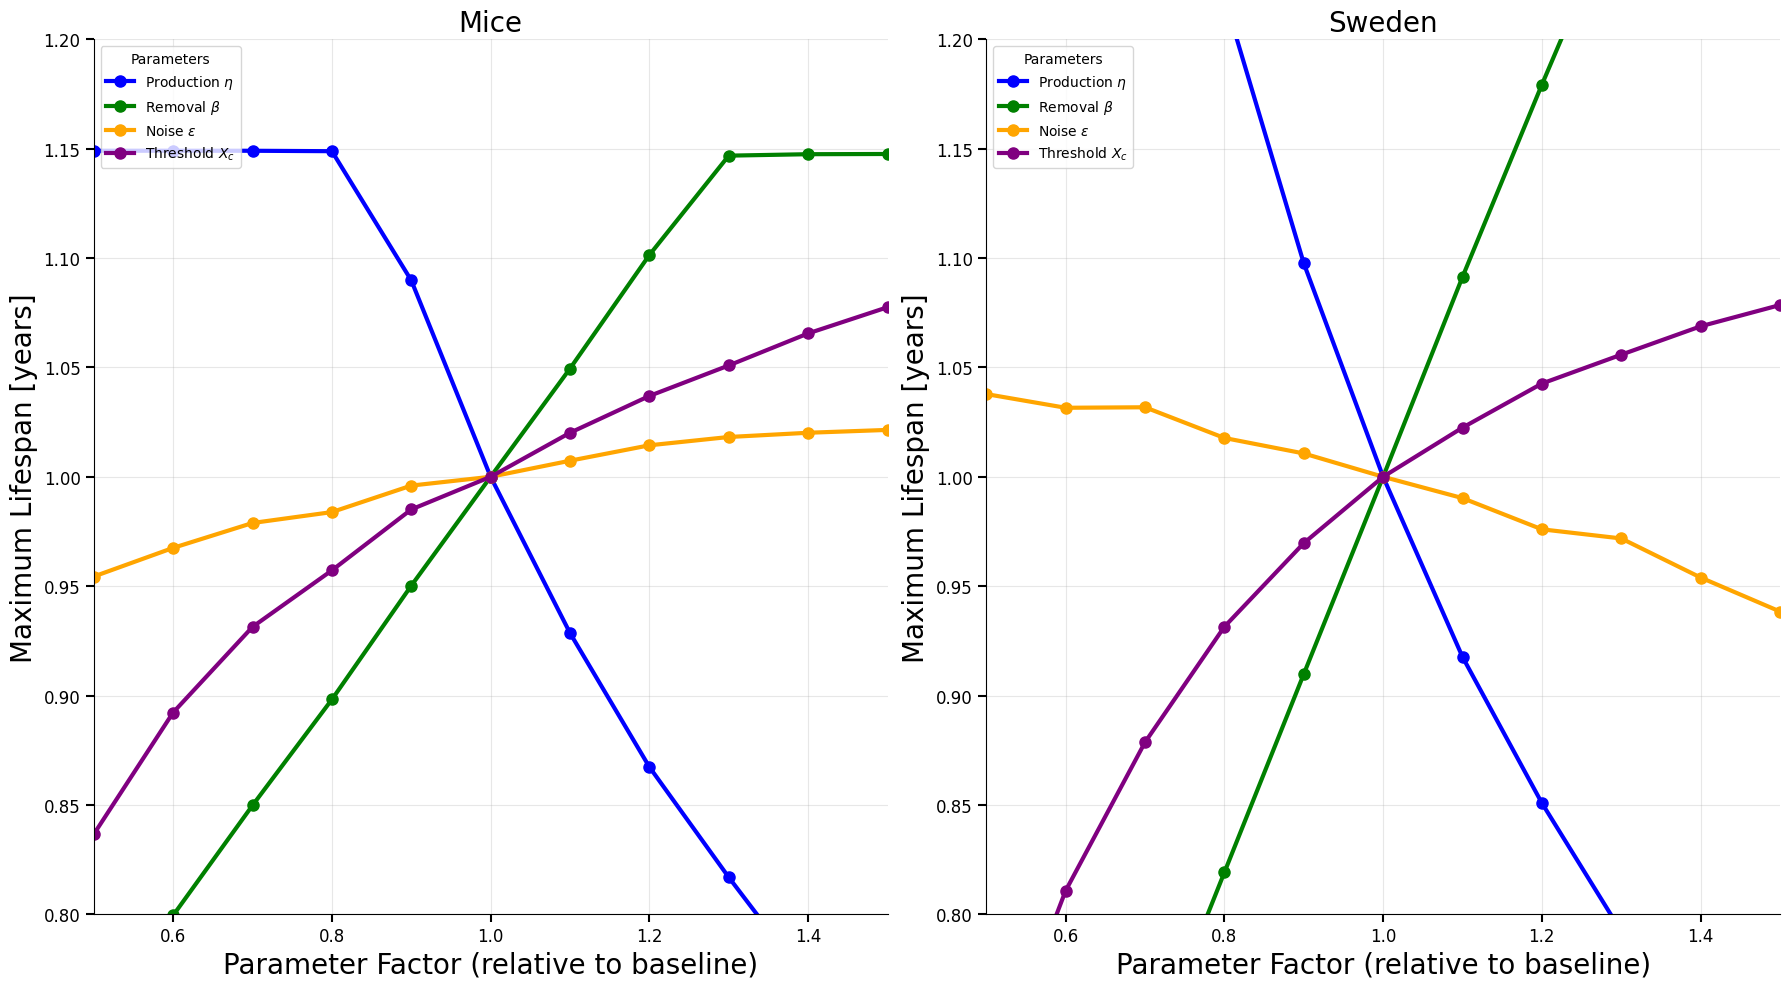

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(18, 10))
fontsize = 20
# Left subplot - Mice
th.plot_max_lifespan_vs_variation(ax=axes[0], pkl_file='param_variation_results_mice.pkl', normalized=True)
axes[0].set_xlim(0.5, 1.5)
axes[0].set_ylim(0.8, 1.2)
axes[0].set_xlabel('Parameter Factor (relative to baseline)', fontsize=fontsize)
axes[0].set_ylabel('Maximum Lifespan [years]', fontsize=fontsize)
axes[0].set_title('Mice', fontsize=fontsize)
axes[0].grid(True, alpha=0.3)

# Right subplot - Sweden
th.plot_max_lifespan_vs_variation(ax=axes[1], pkl_file='param_variation_results_sweden.pkl', normalized=True)
axes[1].set_xlim(0.5, 1.5)
axes[1].set_ylim(0.8, 1.2)
axes[1].set_xlabel('Parameter Factor (relative to baseline)', fontsize=fontsize)
axes[1].set_ylabel('Maximum Lifespan [years]', fontsize=fontsize)
axes[1].set_title('Sweden', fontsize=fontsize)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

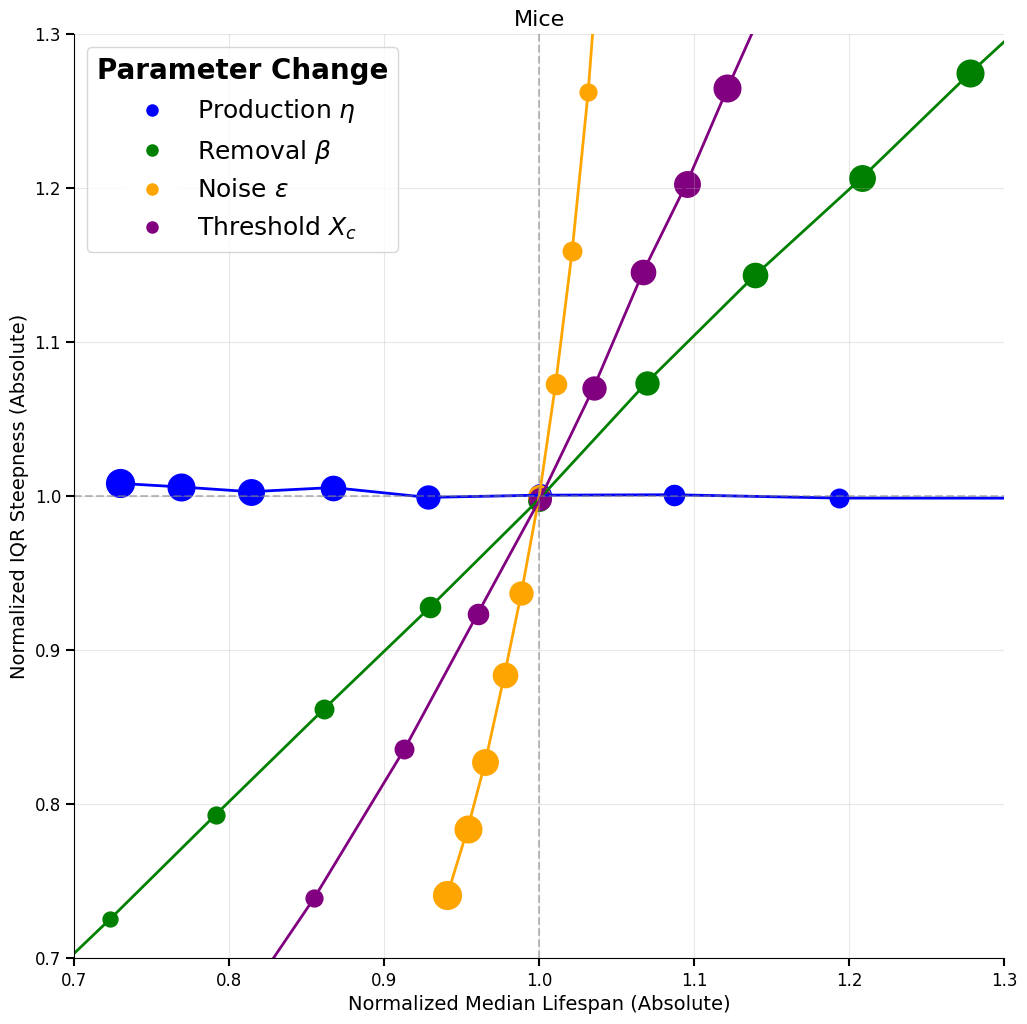

In [21]:
fig, ax = plt.subplots(figsize=(12, 12))
th.plot_steepness_longevity(ax=ax, pkl_file='param_variation_results_mice.pkl', marker_size_range=(20, 400))

ax.set_xlim(0.7, 1.3)
ax.set_ylim(0.7, 1.3)

ax.set_title('Mice', fontsize=16)
ax.grid(True, alpha=0.3)

plt.show()

## Income

In [ ]:
usa_males = HMD(country = 'usa', gender = 'male')
usa_females = HMD(country = 'usa', gender = 'female')



In [ ]:
# Income-based mortality data processing
# Fitting Gompertz survival curves from age-specific mortality data

import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# Men data
men_5th_ages = np.array([47.008547008547005, 54.01709401709401, 55.8974358974359, 62.99145299145299, 68.03418803418805, 71.96581196581198, 75.98290598290599])
men_5th_log_mortality = np.array([-4.921810699588477, -4.477366255144033, -4.362139917695473, -3.9012345679012346, -3.57201646090535, -3.325102880658436, -3.0617283950617287])

men_95th_ages = np.array([45.04273504273504, 53.67521367521367, 61.111111111111114, 66.06837606837608, 71.1965811965812, 76.83760683760686, 81.36752136752138, 49.87179487179487])
men_95th_log_mortality = np.array([-7.037037037037037, -6.164609053497942, -5.415637860082304, -4.91358024691358, -4.395061728395062, -3.82716049382716, -3.3744855967078187, -6.5514403292181065])

# Women data
women_5th_ages = np.array([44.496919917864474, 57.5564681724846, 64.94866529774129, 73.90143737166326, 51.06776180698152, 81.25256673511295])
women_5th_log_mortality = np.array([-5.775280898876404, -4.876404494382021, -4.3520599250936325, -3.737827715355805, -5.318352059925093, -3.2209737827715355])

women_95th_ages = np.array([46.55030800821355, 52.874743326488705, 58.37782340862424, 63.63449691991787, 69.1375770020534, 74.88706365503081])
women_95th_log_mortality = np.array([-7.39325842696629, -6.749063670411983, -6.164794007490635, -5.625468164794007, -5.0561797752808975, -4.45692883895131])

# Function to fit linear relationship: log(mortality) = log(A) + beta * age
def linear_fit(age, log_A, beta):
    return log_A + beta * age

# Fit Gompertz parameters for each group
def fit_gompertz_params(ages, log_mortality):
    # Sort by age for proper fitting
    sorted_indices = np.argsort(ages)
    ages_sorted = ages[sorted_indices]
    log_mortality_sorted = log_mortality[sorted_indices]
    
    # Fit linear relationship
    popt, pcov = curve_fit(linear_fit, ages_sorted, log_mortality_sorted)
    log_A, beta = popt
    A = np.exp(log_A)
    return A, beta, ages_sorted, log_mortality_sorted

# Function to calculate Gompertz survival
def gompertz_survival(t, A, beta):
    return np.exp(-A/beta * (np.exp(beta * t) - 1))

# Fit parameters for all groups
men_5th_A, men_5th_beta, men_5th_ages_sorted, men_5th_log_mort_sorted = fit_gompertz_params(men_5th_ages, men_5th_log_mortality)
men_95th_A, men_95th_beta, men_95th_ages_sorted, men_95th_log_mort_sorted = fit_gompertz_params(men_95th_ages, men_95th_log_mortality)
women_5th_A, women_5th_beta, women_5th_ages_sorted, women_5th_log_mort_sorted = fit_gompertz_params(women_5th_ages, women_5th_log_mortality)
women_95th_A, women_95th_beta, women_95th_ages_sorted, women_95th_log_mort_sorted = fit_gompertz_params(women_95th_ages, women_95th_log_mortality)

print("Fitted Gompertz parameters:")
print(f"Men 5th percentile: A = {men_5th_A:.6f}, β = {men_5th_beta:.6f}")
print(f"Men 95th percentile: A = {men_95th_A:.6f}, β = {men_95th_beta:.6f}")
print(f"Women 5th percentile: A = {women_5th_A:.6f}, β = {women_5th_beta:.6f}")
print(f"Women 95th percentile: A = {women_95th_A:.6f}, β = {women_95th_beta:.6f}")

# Generate survival curves from t=0 to t=100
age_range = np.linspace(0, 120, 1000)

men_5th_survival = gompertz_survival(age_range, men_5th_A, men_5th_beta)
men_95th_survival = gompertz_survival(age_range, men_95th_A, men_95th_beta)
women_5th_survival = gompertz_survival(age_range, women_5th_A, women_5th_beta)
women_95th_survival = gompertz_survival(age_range, women_95th_A, women_95th_beta)

# Plot all survival curves on the same plot
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Men - low income (5th percentile) with square markers and low alpha
ax.plot(age_range, men_5th_survival, 'b-', alpha=0.5, linewidth=2, 
        marker='s', markersize=3, markevery=50, label='Men 5th percentile income')

# Men - high income (95th percentile) with star markers
ax.plot(age_range, men_95th_survival, 'b-', linewidth=2, 
        marker='*', markersize=6, markevery=50, label='Men 95th percentile income')

# Women - low income (5th percentile) with square markers and low alpha
ax.plot(age_range, women_5th_survival, 'r-', alpha=0.5, linewidth=2, 
        marker='s', markersize=3, markevery=50, label='Women 5th percentile income')

# Women - high income (95th percentile) with star markers
ax.plot(age_range, women_95th_survival, 'r-', linewidth=2, 
        marker='*', markersize=6, markevery=50, label='Women 95th percentile income')

ax.set_xlabel('Age (years)')
ax.set_ylabel('Survival probability')
ax.set_title('Survival Curves by Gender and Income Level')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1)
ax.set_xlim(0, 120)


# Calculate steepness metrics by interpolating survival curves
def calculate_steepness_from_survival_curve(age_range, survival_curve):
    # Find ages at 75%, 50%, and 25% survival by interpolation
    survival_levels = [0.75, 0.50, 0.25]
    ages = []
    
    for s in survival_levels:
        # Find the age where survival equals the target level
        # Use interpolation to find exact age
        if np.any(survival_curve >= s) and np.any(survival_curve <= s):
            # Find indices where survival crosses the target level
            idx = np.where(survival_curve <= s)[0]
            if len(idx) > 0:
                # Use linear interpolation between the crossing points
                if idx[0] == 0:
                    age = age_range[0]
                else:
                    # Interpolate between the two points
                    i = idx[0]
                    x1, x2 = age_range[i-1], age_range[i]
                    y1, y2 = survival_curve[i-1], survival_curve[i]
                    age = x1 + (s - y1) * (x2 - x1) / (y2 - y1)
                ages.append(age)
            else:
                ages.append(np.nan)
        else:
            ages.append(np.nan)
    
    if not any(np.isnan(ages)):
        t_75, t_50, t_25 = ages
        steepness = -t_50 / (t_75 - t_25)
        return steepness, t_50, t_75, t_25
    else:
        return np.nan, np.nan, np.nan, np.nan

# Calculate steepness for each group using interpolation
income_results = {}
survival_curves = [
    ("Men 5th percentile", men_5th_survival, men_5th_A, men_5th_beta),
    ("Men 95th percentile", men_95th_survival, men_95th_A, men_95th_beta),
    ("Women 5th percentile", women_5th_survival, women_5th_A, women_5th_beta),
    ("Women 95th percentile", women_95th_survival, women_95th_A, women_95th_beta)
]

print("\nSteepness analysis for income groups (using interpolation):")
for name, survival_curve, A, beta in survival_curves:
    steepness, median_t, t_75, t_25 = calculate_steepness_from_survival_curve(age_range, survival_curve)
    income_results[name] = {
        'steepness': steepness,
        'median_lifespan': median_t,
        't_75': t_75,
        't_25': t_25,
        'A': A,
        'beta': beta
    }
    print(f"{name}:")
    print(f"  Steepness: {steepness:.3f}")
    print(f"  Median lifespan: {median_t:.2f} years")
    print(f"  A: {A:.6f}, β: {beta:.6f}")
    
    
usa_males.plot_survival(ax=ax, years = 2007, custom_colors = ['teal'])
usa_females.plot_survival(ax=ax, years = 2007, custom_colors = ['magenta'])

plt.tight_layout()
plt.show()


In [ ]:
# Men data
men_5th_ages = np.array([47.008547008547005, 54.01709401709401, 55.8974358974359, 62.99145299145299, 68.03418803418805, 71.96581196581198, 75.98290598290599])
men_5th_log_mortality = np.array([-4.921810699588477, -4.477366255144033, -4.362139917695473, -3.9012345679012346, -3.57201646090535, -3.325102880658436, -3.0617283950617287])

men_95th_ages = np.array([45.04273504273504, 53.67521367521367, 61.111111111111114, 66.06837606837608, 71.1965811965812, 76.83760683760686, 81.36752136752138, 49.87179487179487])
men_95th_log_mortality = np.array([-7.037037037037037, -6.164609053497942, -5.415637860082304, -4.91358024691358, -4.395061728395062, -3.82716049382716, -3.3744855967078187, -6.5514403292181065])

# Women data
women_5th_ages = np.array([44.496919917864474, 57.5564681724846, 64.94866529774129, 73.90143737166326, 51.06776180698152, 81.25256673511295])
women_5th_log_mortality = np.array([-5.775280898876404, -4.876404494382021, -4.3520599250936325, -3.737827715355805, -5.318352059925093, -3.2209737827715355])

women_95th_ages = np.array([46.55030800821355, 52.874743326488705, 58.37782340862424, 63.63449691991787, 69.1375770020534, 74.88706365503081])
women_95th_log_mortality = np.array([-7.39325842696629, -6.749063670411983, -6.164794007490635, -5.625468164794007, -5.0561797752808975, -4.45692883895131])

fig, ax = plt.subplots(figsize=(16, 16))
usa_males.plot_hazard(ax=ax, years = 2007)
usa_females.plot_hazard(ax=ax, years = 2007)

# Add empirical data points as markers
ax.scatter(men_5th_ages, np.exp(men_5th_log_mortality), marker='s', s=60, color='blue', alpha=0.7, label='Men 5th percentile')
ax.scatter(men_95th_ages, np.exp(men_95th_log_mortality), marker='^', s=60, color='lightblue', alpha=0.7, label='Men 95th percentile')
ax.scatter(women_5th_ages, np.exp(women_5th_log_mortality), marker='o', s=60, color='red', alpha=0.7, label='Women 5th percentile')
ax.scatter(women_95th_ages, np.exp(women_95th_log_mortality), marker='D', s=60, color='pink', alpha=0.7, label='Women 95th percentile')

baseline_plotter.plot_hazard(ax=ax)

ax.legend()

plt.show()


## BIG BEAUTIFUL PLOT

In [ ]:
# Define empirical data for various cohorts
# Data format: (t_75, survival_75), (t_50, survival_50), (t_25, survival_25)

# Males general population
males_general_t_75, males_general_t_50, males_general_t_25 = 38.12, 50.31, 59.79
males_general_median_t = males_general_t_50
males_general_steepness = -males_general_median_t / (males_general_t_75 - males_general_t_25)

# Males olympians
males_olympians_t_75, males_olympians_t_50, males_olympians_t_25 = 46.27, 56.66, 64.53
males_olympians_median_t = males_olympians_t_50
males_olympians_steepness = -males_olympians_median_t / (males_olympians_t_75 - males_olympians_t_25)

# Females general population
females_general_t_75, females_general_t_50, females_general_t_25 = 51.43, 61.81, 69.55
females_general_median_t = females_general_t_50
females_general_steepness = -females_general_median_t / (females_general_t_75 - females_general_t_25)

# Females olympians
females_olympians_t_75, females_olympians_t_50, females_olympians_t_25 = 57.07, 66.13, 71.36
females_olympians_median_t = females_olympians_t_50
females_olympians_steepness = -females_olympians_median_t / (females_olympians_t_75 - females_olympians_t_25)

# Progeria patients
progeria_t_75, progeria_t_50, progeria_t_25 = 11.54, 14.51, 17.34
progeria_median_t = progeria_t_50
progeria_steepness = -progeria_median_t / (progeria_t_75 - progeria_t_25)

# Polish male athletes
polish_athletes_t_75, polish_athletes_t_50, polish_athletes_t_25 = 71.04, 81.24, 87.39
polish_athletes_median_t = polish_athletes_t_50
polish_athletes_steepness = -polish_athletes_median_t / (polish_athletes_t_75 - polish_athletes_t_25)

# Polish male monks
polish_monks_t_75, polish_monks_t_50, polish_monks_t_25 = 66.97, 75.93, 85.39
polish_monks_median_t = polish_monks_t_50
polish_monks_steepness = -polish_monks_median_t / (polish_monks_t_75 - polish_monks_t_25)

# Polish male actors
polish_actors_t_75, polish_actors_t_50, polish_actors_t_25 = 64.56, 73.28, 82.16
polish_actors_median_t = polish_actors_t_50
polish_actors_steepness = -polish_actors_median_t / (polish_actors_t_75 - polish_actors_t_25)

# Get HMD reference data for normalization
usa_males_steepness_2007 = usa_males.calculate_steepness(2007, age_start=0)
usa_females_steepness_2007 = usa_females.calculate_steepness(2007, age_start=0)
usa_males_median_2007 = usa_males.calculate_median_lifespan(2007, age_start=0)
usa_females_median_2007 = usa_females.calculate_median_lifespan(2007, age_start=0)

### plotting ###

fig, ax = plt.subplots(figsize=(16, 16))
plot_steepness_longevity(param_type='variation', from_t=0, ax=ax, steepness_method = 'iqr')
# Add empirical data points with normalization
# Extract baseline values for normalization
baseline_steepness = baseline_results[0]['steepness_iqr']
baseline_median = baseline_results[0]['t_median']

# Plot progeria normalized by baseline
progeria_norm_steepness = progeria_steepness / baseline_steepness
progeria_norm_median = progeria_median_t / baseline_median
ax.scatter(progeria_norm_median, progeria_norm_steepness, s=200, c='red', marker='o', 
           edgecolors='black', linewidth=2, zorder=10)
ax.text(progeria_norm_median, progeria_norm_steepness + 0.03, 'Progeria', 
        ha='center', va='bottom', fontsize=12, fontweight='bold')

# Plot olympians normalized by general population
males_olympians_norm_steepness = males_olympians_steepness / males_general_steepness
males_olympians_norm_median = males_olympians_median_t / males_general_median_t
ax.scatter(males_olympians_norm_median, males_olympians_norm_steepness, s=200, c='blue', marker='o',
           edgecolors='black', linewidth=2, zorder=10)
ax.text(males_olympians_norm_median, males_olympians_norm_steepness + 0.03, 'Male Olympians', 
        ha='center', va='bottom', fontsize=12, fontweight='bold')

females_olympians_norm_steepness = females_olympians_steepness / females_general_steepness
females_olympians_norm_median = females_olympians_median_t / females_general_median_t
ax.scatter(females_olympians_norm_median, females_olympians_norm_steepness, s=200, c='pink', marker='o',
           edgecolors='black', linewidth=2, zorder=10)
ax.text(females_olympians_norm_median, females_olympians_norm_steepness + 0.03, 'Female Olympians', 
        ha='center', va='bottom', fontsize=12, fontweight='bold')
'''
# Plot Polish athletes and monks normalized by actors
polish_athletes_norm_steepness = polish_athletes_steepness / polish_actors_steepness
polish_athletes_norm_median = polish_athletes_median_t / polish_actors_median_t
ax.scatter(polish_athletes_norm_median, polish_athletes_norm_steepness, s=200, c='green', marker='o',
           edgecolors='black', linewidth=2, zorder=10)
ax.text(polish_athletes_norm_median, polish_athletes_norm_steepness + 0.03, 'Polish Athletes / Actors', 
        ha='center', va='bottom', fontsize=12, fontweight='bold')

polish_monks_norm_steepness = polish_monks_steepness / polish_actors_steepness
polish_monks_norm_median = polish_monks_median_t / polish_actors_median_t
ax.scatter(polish_monks_norm_median, polish_monks_norm_steepness, s=200, c='purple', marker='o',
           edgecolors='black', linewidth=2, zorder=10)
ax.text(polish_monks_norm_median, polish_monks_norm_steepness + 0.03, 'Polish Monks / Actors', 
        ha='center', va='bottom', fontsize=12, fontweight='bold')

'''
# Plot sleep duration categories normalized by general NHANES population
for sleep_cat, results in sleep_results.items():
    if sleep_cat != "All NHANES participants":  # Skip the reference group
        sleep_norm_steepness = results['steepness'] / sleep_results["All NHANES participants"]['steepness']
        sleep_norm_median = results['median_lifespan'] / sleep_results["All NHANES participants"]['median_lifespan']
        
        # Choose colors for different sleep categories
        color_map = {
            "<5 h": "orange", 
            "5-<7 h": "lightblue", 
            "7-<9 h": "lightgreen", 
            "≥9 h": "yellow"
        }
        color = color_map.get(sleep_cat, "gray")
        
        ax.scatter(sleep_norm_median, sleep_norm_steepness, s=200, c=color, marker='o',
                   edgecolors='black', linewidth=2, zorder=10)
        ax.text(sleep_norm_median, sleep_norm_steepness + 0.03, f'Sleep {sleep_cat}', 
                ha='center', va='bottom', fontsize=12, fontweight='bold')
'''
# Plot income results normalized by USA HMD data for 2007
for name, results in income_results.items():
    if 'Men' in name:
        # Normalize male income groups by USA males 2007
        income_norm_steepness = results['steepness'] / usa_males_steepness_2007
        income_norm_median = results['median_lifespan'] / usa_males_median_2007
        color = 'darkblue' if '5th percentile' in name else 'lightblue'
        marker_style = 's'  # square for income data
    elif 'Women' in name:
        # Normalize female income groups by USA females 2007
        income_norm_steepness = results['steepness'] / usa_females_steepness_2007
        income_norm_median = results['median_lifespan'] / usa_females_median_2007
        color = 'darkred' if '5th percentile' in name else 'lightcoral'
        marker_style = 's'  # square for income data
    
    ax.scatter(income_norm_median, income_norm_steepness, s=200, c=color, marker=marker_style,
               edgecolors='black', linewidth=2, zorder=10)
    
    # Create shorter labels for better display
    short_name = name.replace(' percentile', '%')
    ax.text(income_norm_median, income_norm_steepness + 0.03, short_name, 
            ha='center', va='bottom', fontsize=10, fontweight='bold')
            
'''

# Plot high/low income ratios
# For men
men_high = next((results for name, results in income_results.items() if 'Men' in name and '95th' in name), None)
men_low = next((results for name, results in income_results.items() if 'Men' in name and '5th' in name), None)
if men_high and men_low:
    men_ratio_steepness = men_high['steepness'] / men_low['steepness']
    men_ratio_median = men_high['median_lifespan'] / men_low['median_lifespan']
    ax.scatter(men_ratio_median, men_ratio_steepness, s=200, c='navy', marker='*',
               edgecolors='black', linewidth=2, zorder=10)
    ax.text(men_ratio_median, men_ratio_steepness + 0.03, 'Men High/Low Income', 
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# For women
women_high = next((results for name, results in income_results.items() if 'Women' in name and '95th' in name), None)
women_low = next((results for name, results in income_results.items() if 'Women' in name and '5th' in name), None)
if women_high and women_low:
    women_ratio_steepness = women_high['steepness'] / women_low['steepness']
    women_ratio_median = women_high['median_lifespan'] / women_low['median_lifespan']
    ax.scatter(women_ratio_median, women_ratio_steepness, s=200, c='crimson', marker='*',
               edgecolors='black', linewidth=2, zorder=10)
    ax.text(women_ratio_median, women_ratio_steepness + 0.03, 'Women High/Low Income', 
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Turn off the unused subplot


plt.tight_layout()
plt.show()


# BIG BEAUTIFUL PLOT PART 2

In [2]:
interventions_dict = nhanes.load_interventions_dict()
interventions_dict.keys()

Loaded exposure group results from /Users/benshenhar/Library/CloudStorage/GoogleDrive-benshenhar@gmail.com/My Drive/Weizmann/Alon Lab/Aging/python/notebooks/thresholds, noise/saved_results/exposure_groups_results.pkl


dict_keys(['baseline', 'diet', 'income', 'alcohol', 'physical_activity', 'sleep_duration', 'sleep_frailty', 'work_regularity', 'number_of_friends', 'church_frequency', 'education_level'])

/var/folders/r5/2q8zzrr15ld3_jcs6mjrvk900000gn/T/ipykernel_51920/2044309060.py:60: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig.legend()


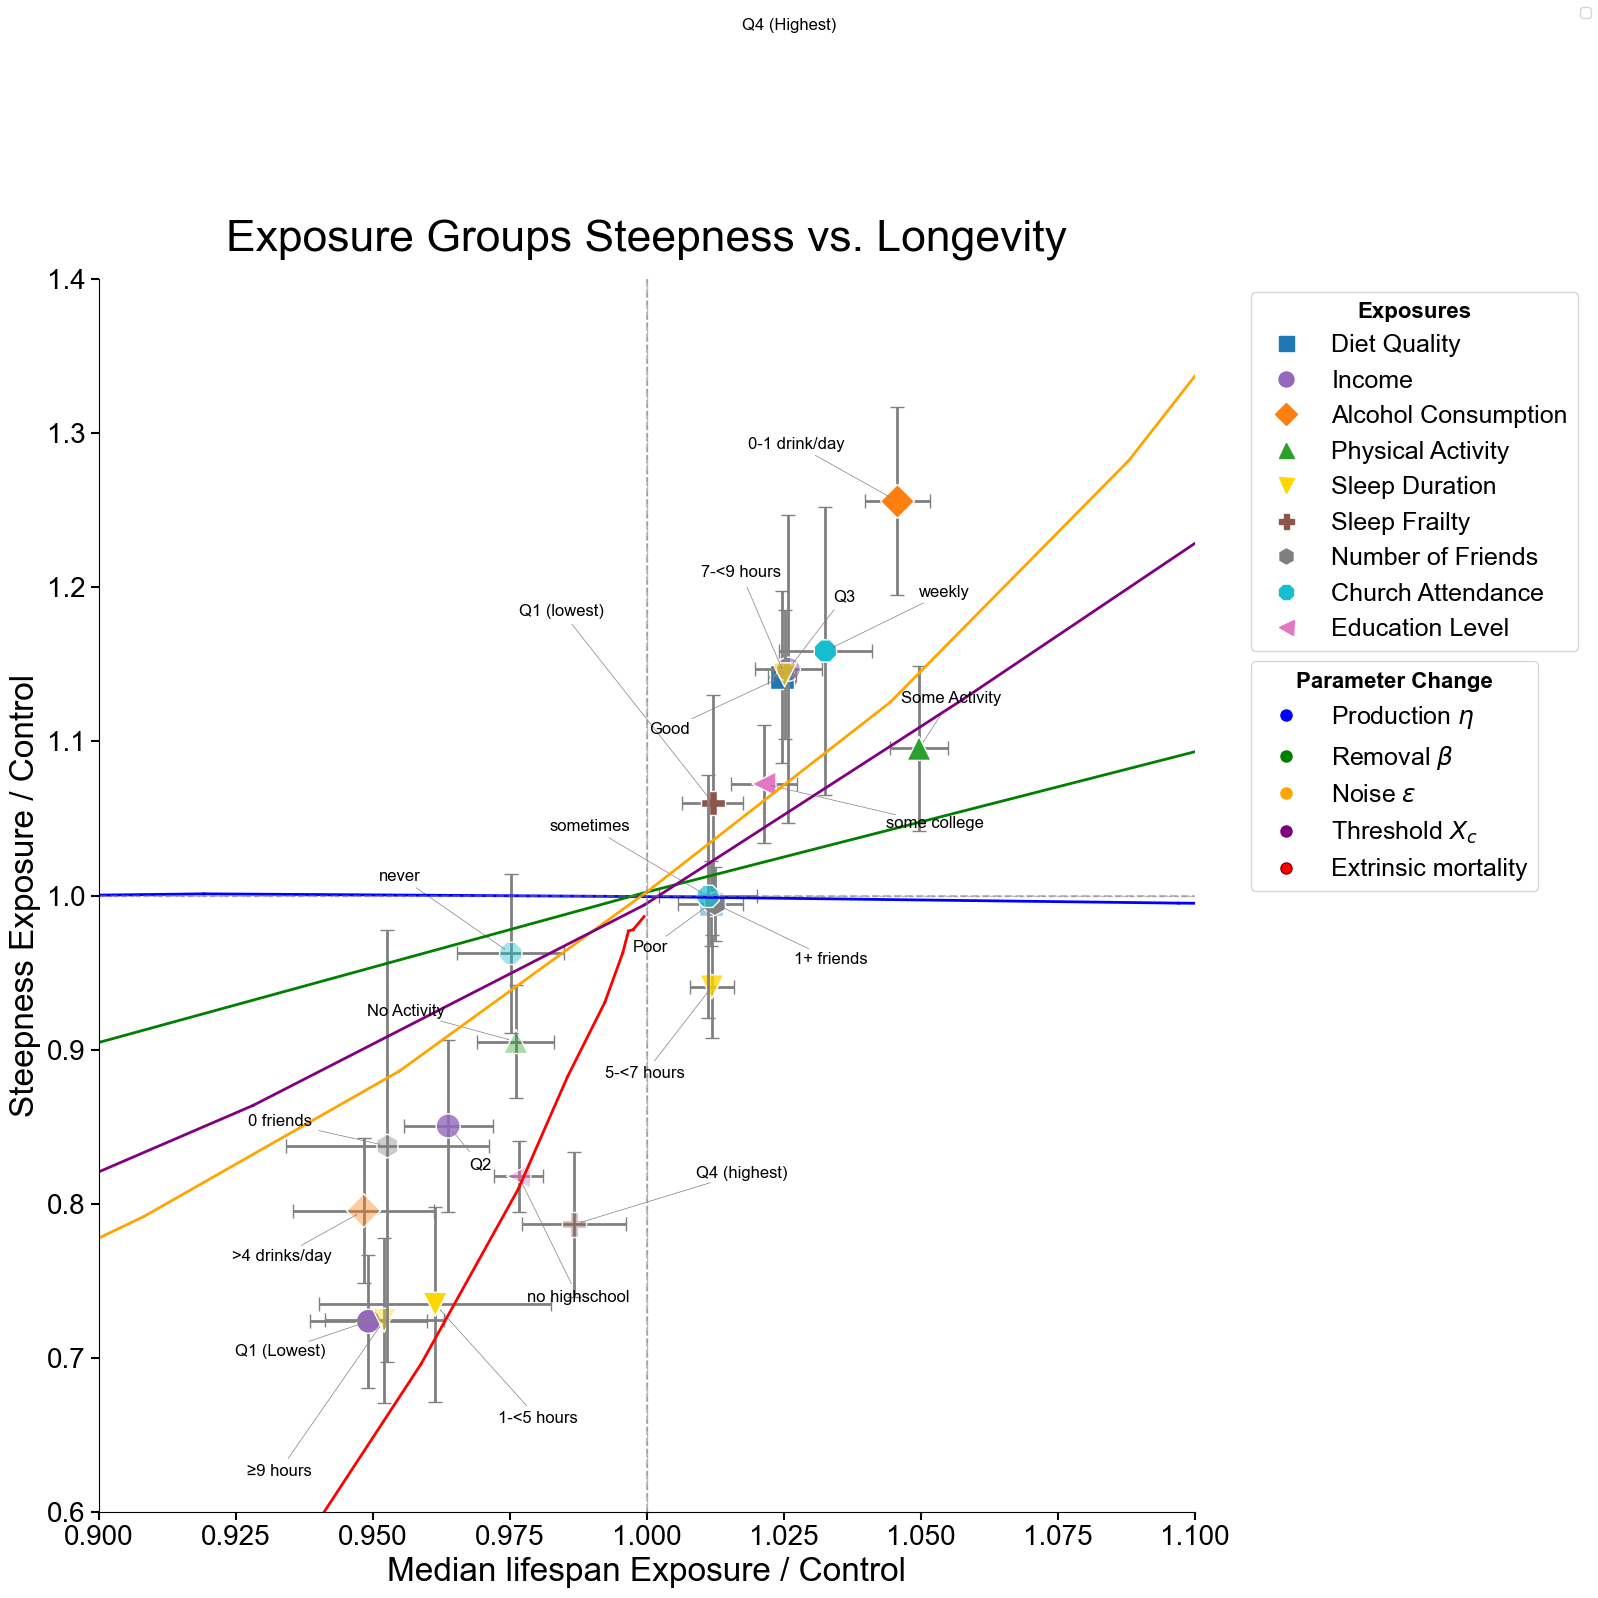

In [8]:
fig, ax1 = plt.subplots(1, 1, figsize=(16, 16))
# keep 70 % of the width for the data; leave 30 % blank on the right
box = ax1.get_position()                    # (x0, y0, w, h)
plt.rcParams['font.family'] = 'Arial'

# First plot with IQR steepness
steepness_metric_iqr = 'steepness_iqr_absolute'
longevity_metric = 't_median_absolute'
baseline_type = 'without_extrinsic'

topics = ['diet', 'income', 'alcohol', 'physical_activity', 'sleep_duration', 'sleep_frailty', 'number_of_friends', 'church_frequency', 'education_level']
_, legend_nhanes = nhanes.plot_intervention_steepness_longevity(
    topics=topics,
    ax=ax1,
    from_t=20,
    steepness_metric=steepness_metric_iqr,
    longevity_metric=longevity_metric,
    baseline_type=baseline_type,
    label_points=True,
    marker_size=300
)


legend = th.plot_steepness_longevity(param_type='variation', from_t=20, ax=ax1, 
                            steepness_metric=steepness_metric_iqr, longevity_metric=longevity_metric,
                            h_ext=True, linewidth=2, marker_size_range=(0,0))

# remove all existing legends
for legend_obj in ax1.get_legend_handles_labels()[0]:
    if hasattr(legend_obj, 'remove'):
        legend_obj.remove()
if ax1.get_legend():
    ax1.get_legend().remove()
    

# Position legends to the right of the plot, stacked vertically
legend_nhanes.set_bbox_to_anchor((1.04, 1))  # top right, just outside plot
legend_nhanes._loc = 2 # 'upper left'
legend.set_bbox_to_anchor((1.04, 0.7))  # a bit below the first legend
legend._loc = 2  # 'upper left'
# Add both legends back

ax1.add_artist(legend)
ax1.add_artist(legend_nhanes)


ax1.set_xlim(0.8, 1.2)
ax1.set_ylim(0.5, 1.4)
ax1.set_title('', fontsize=24, pad=20, fontfamily='Arial')
# remove grid
ax1.grid(False)

ax1.set_xlim(0.9, 1.1)
ax1.set_ylim(0.6, 1.4)
ax1.set_title('Exposure Groups Steepness vs. Longevity', fontsize=32, pad=20, fontfamily='Arial')
ax1.set_xlabel(f"Median lifespan Exposure / Control", fontsize=24)
ax1.set_ylabel(f"Steepness Exposure / Control", fontsize=24)
ax1.tick_params(axis='both', which='major', labelsize=20)  # Increase tick label size
# save as png
fig.legend()
fig.tight_layout()
fig.subplots_adjust(right=0.75)
plt.show()

# Steepness CV exakmination

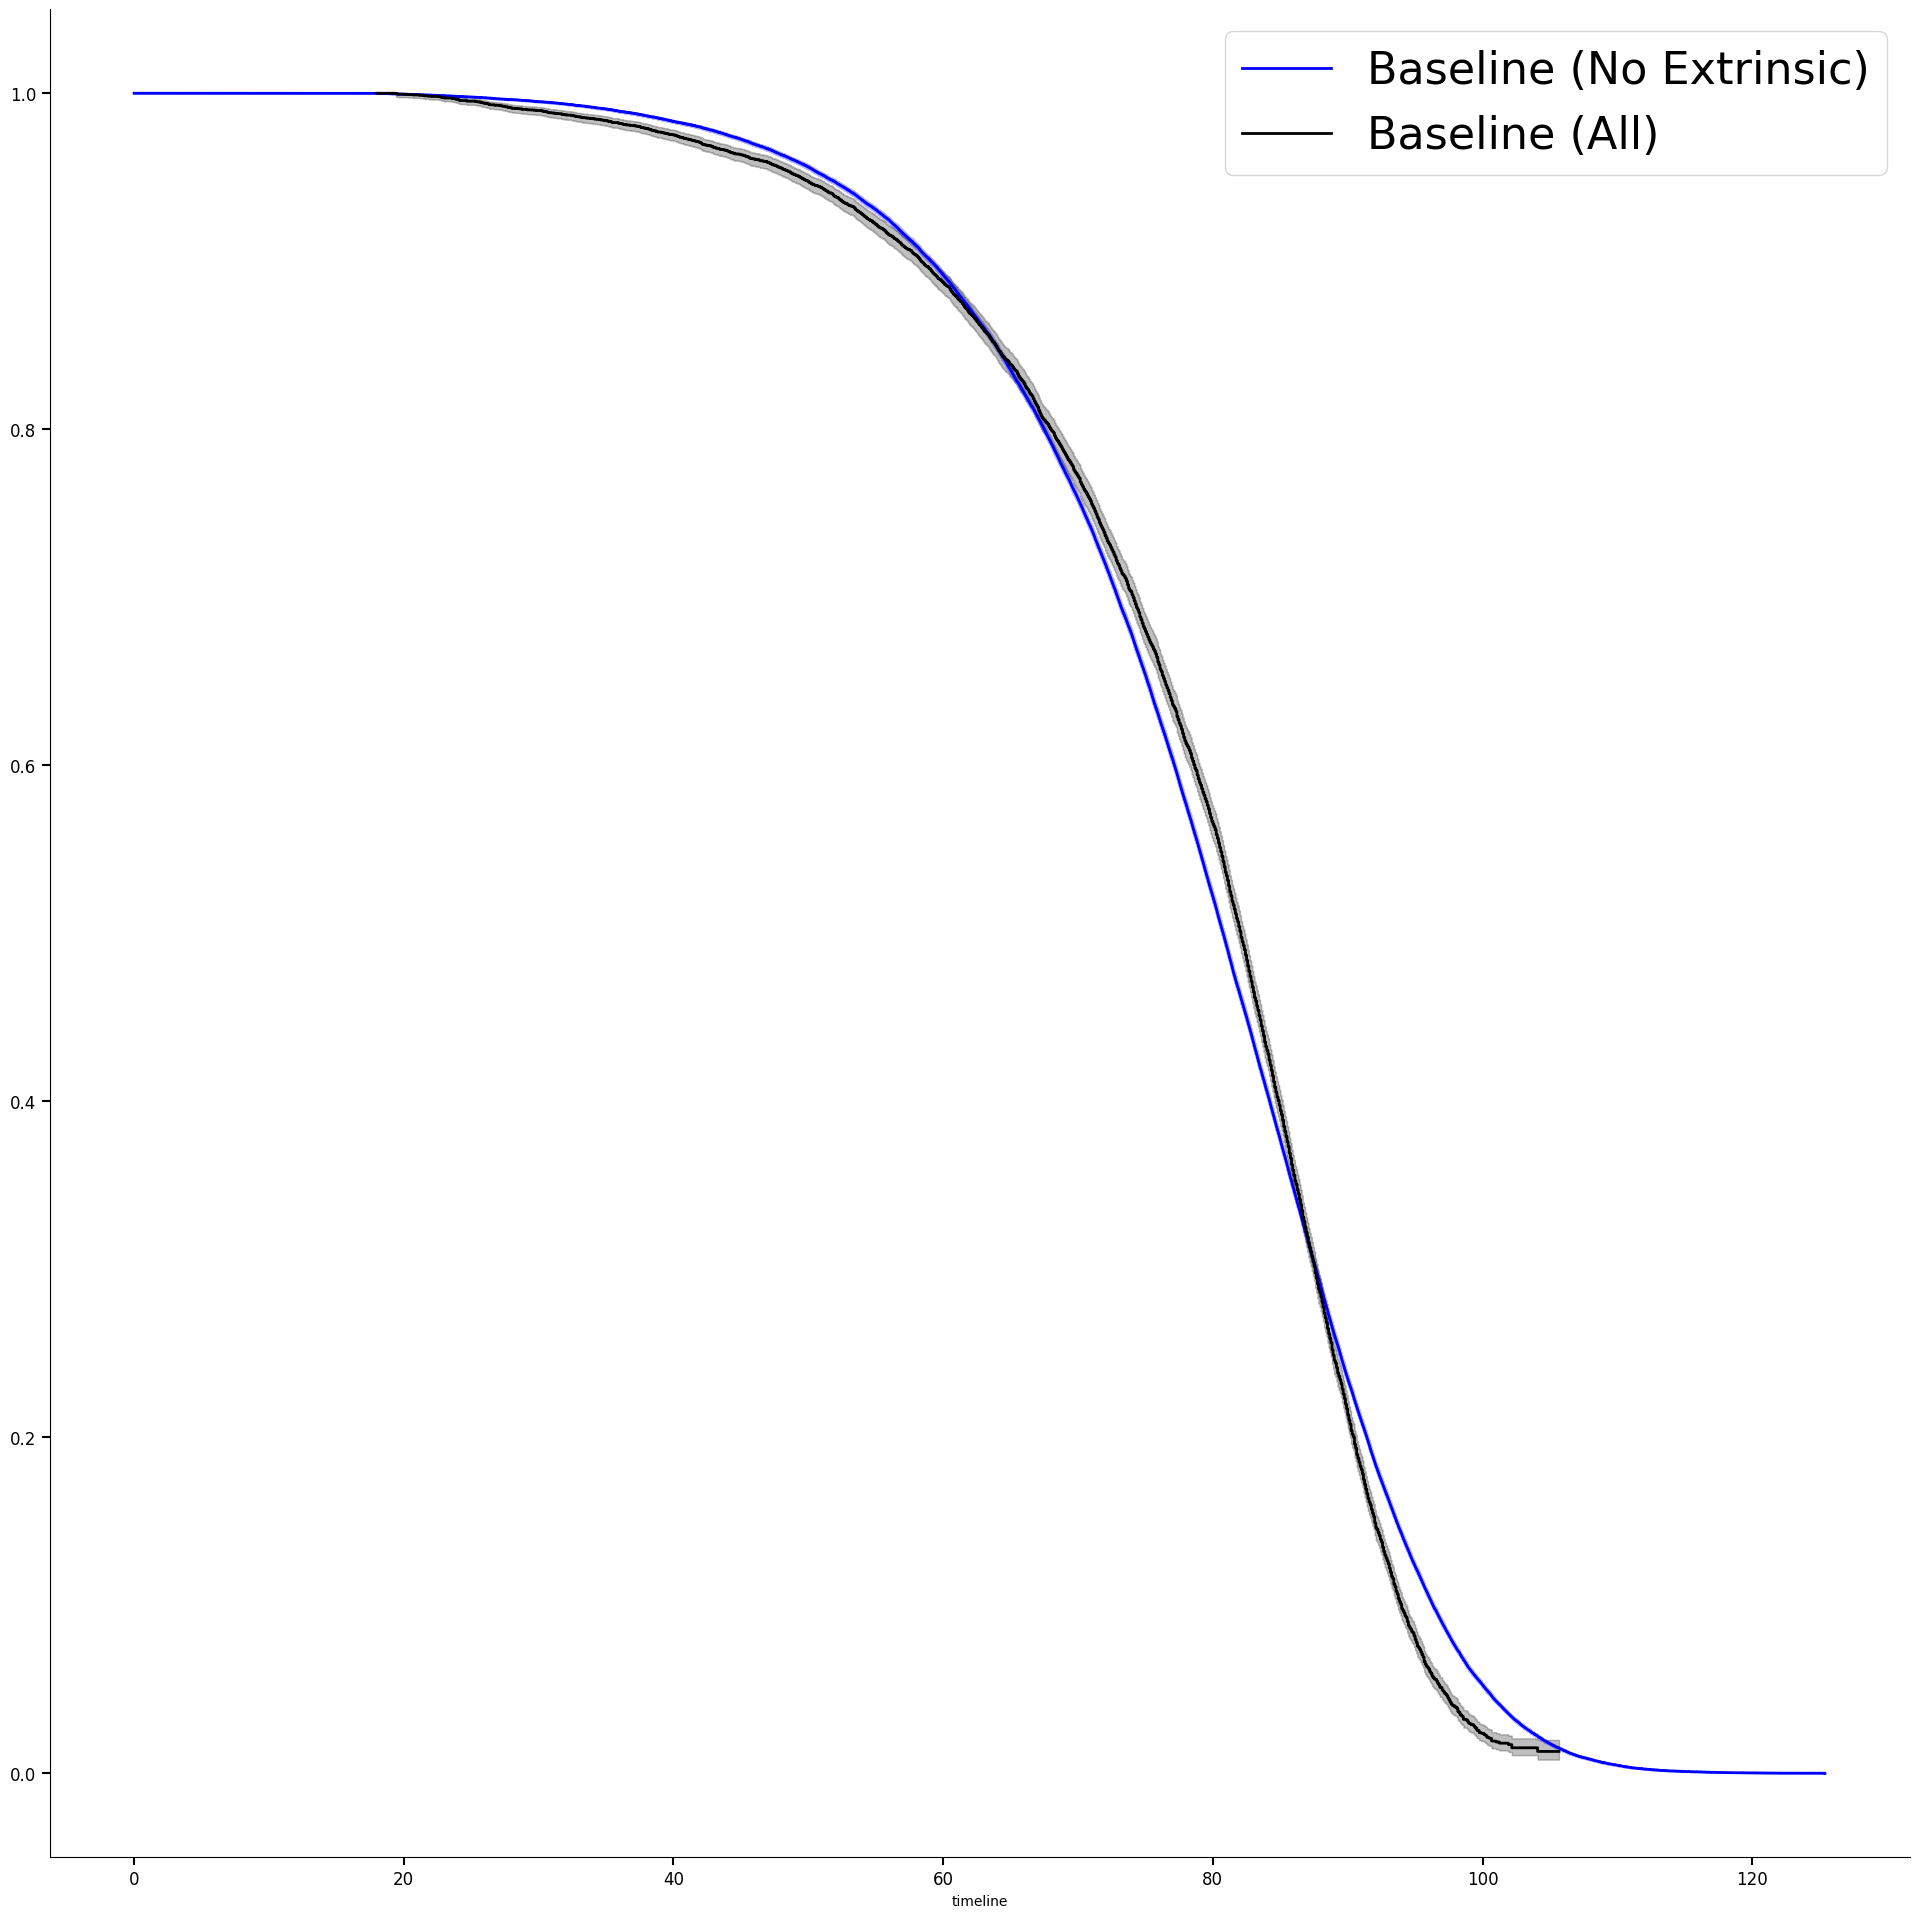

In [15]:
fig, ax = plt.subplots(figsize=(24, 24))
nhanes.plot_baseline_km(ax, without_extrinsic=True)
nhanes.plot_baseline_km(ax, without_extrinsic=False)
ax.legend(fontsize=32)


Value counts for sleep_duration:
sleep_hours_group
7-<9 hours    22189
5-<7 hours    12255
≥9 hours       5389
1-<5 hours     2092
Name: count, dtype: int64


<Axes: title={'center': 'Survival by Sleep Duration'}, xlabel='Age (years)', ylabel='Survival Probability'>

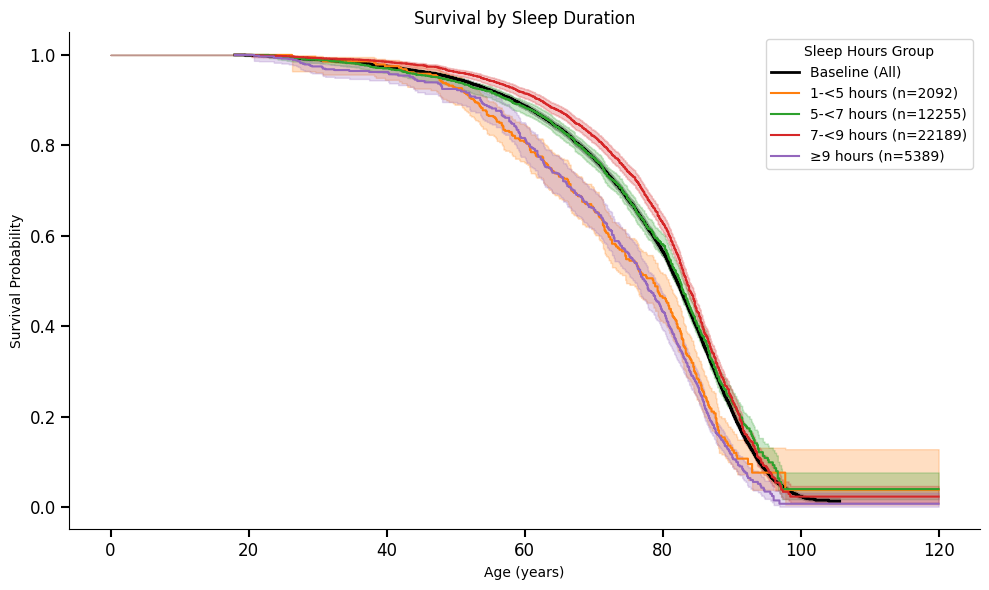

In [8]:
nhanes.plot_survival_by_topic(topic_name = 'sleep_duration', with_extrinsic=True)

# Uri's alternative idea

In [12]:
# Load baseline parameters and setup
base_dict = utils.load_baseline_human_params_dict()
n = int(1e4)
from_t_values = [0, 15, 20, 40, 50]

# Helper function to prepare parameter dictionary
def prepare_params_dict(base_dict, n, param=None, factor=1.0):
    """Prepare parameter dictionary with proper array expansion."""
    dict_copy = base_dict.copy()
    for key in dict_copy.keys():
        if isinstance(dict_copy[key], (np.ndarray, list)) and len(dict_copy[key]) == 1:
            dict_copy[key] = np.repeat(dict_copy[key], n)
        elif np.isscalar(dict_copy[key]):
            dict_copy[key] = np.repeat(np.array([dict_copy[key]]), n)
    
    if param:
        dict_copy[param] = factor * dict_copy[param]
    
    return dict_copy

# Helper function to extract survival curves (timeline + survival array) from SR_sim instance
def extract_survival_curves(sim, from_t_values):
    """
    For each from_t value, extract the survival curve: timeline and S(t) arrays.
    Returns:
        curves: dict mapping from_t -> {'timeline': ..., 'survival': ...}
    """
    curves = {}
    for from_t in from_t_values:
        # Create conditional KMF for from_t
        kmf = sim._create_survival_from_t(from_t)
        if kmf is not None:
            curves[from_t] = {
                'timeline': kmf.survival_function_.index.values.copy(),
                'survival': kmf.survival_function_["KM_estimate"].values.copy() if "KM_estimate" in kmf.survival_function_.columns else kmf.survival_function_.iloc[:, 0].values.copy()
            }
        else:
            curves[from_t] = {
                'timeline': None,
                'survival': None
            }
    return curves

# Run baseline simulation
baseline_dict = prepare_params_dict(base_dict, n)
baseline_sim = utils.create_sr_simulation(params_dict=baseline_dict, n=n, parallel=False)
baseline_survival_curves = extract_survival_curves(baseline_sim, from_t_values)

# Initialize results structure for survival curves
results = {'baseline': baseline_survival_curves}

# Parameter variation study
params = ['eta', 'beta', 'kappa', 'epsilon', 'Xc']

factors = np.arange(0.5, 1.51, 0.1)

for param in params:
    print(f"Processing parameter: {param}")
    results[param] = {}
    
    for factor in factors:
        param_dict = prepare_params_dict(base_dict, n, param, factor)
        sim = utils.create_sr_simulation(params_dict=param_dict, n=n, parallel=False, tmax = 200)
        results[param][factor] = extract_survival_curves(sim, from_t_values)
        print(f"  Factor: {factor:.2f} completed")

# External hazard variation study
print("\nProcessing h_ext values...")
h_ext_values = np.logspace(-4, -2, 10)
results['h_ext'] = {}

for h_ext in h_ext_values:
    baseline_dict = prepare_params_dict(base_dict, n)
    sim = utils.create_sr_simulation(params_dict=baseline_dict, h_ext=h_ext, n=n, parallel=True)
    results['h_ext'][h_ext] = extract_survival_curves(sim, from_t_values)
    print(f"  h_ext: {h_ext:.2e} completed")

print("\nAll simulations completed and survival curves saved!")

# Results structure guide:
# results = {
#     'baseline': {from_t: {'timeline': array, 'survival': array}},
#     'eta': {factor: {from_t: {'timeline': array, 'survival': array}}},
#     ... and so on for 'beta', 'kappa', 'epsilon', 'Xc', 'h_ext'
# }
#
# Access example:
# - Timeline for eta factor 1.2, from_t=20: results['eta'][1.2][20]['timeline']
# - Survival curve for baseline, from_t=0: results['baseline'][0]['survival']


Processing parameter: eta
  Factor: 0.50 completed
  Factor: 0.60 completed
  Factor: 0.70 completed
  Factor: 0.80 completed
  Factor: 0.90 completed
  Factor: 1.00 completed
  Factor: 1.10 completed
  Factor: 1.20 completed
  Factor: 1.30 completed
  Factor: 1.40 completed
  Factor: 1.50 completed
Processing parameter: beta
  Factor: 0.50 completed
  Factor: 0.60 completed
  Factor: 0.70 completed
  Factor: 0.80 completed
  Factor: 0.90 completed
  Factor: 1.00 completed
  Factor: 1.10 completed
  Factor: 1.20 completed
  Factor: 1.30 completed
  Factor: 1.40 completed
  Factor: 1.50 completed
Processing parameter: kappa
  Factor: 0.50 completed
  Factor: 0.60 completed
  Factor: 0.70 completed
  Factor: 0.80 completed
  Factor: 0.90 completed
  Factor: 1.00 completed
  Factor: 1.10 completed
  Factor: 1.20 completed
  Factor: 1.30 completed
  Factor: 1.40 completed
  Factor: 1.50 completed
Processing parameter: epsilon
  Factor: 0.50 completed
  Factor: 0.60 completed
  Factor: 0.70

In [15]:
import numpy as np

def compute_t_median_from_survival_curve(timeline, survival, min_S=0.5):
    """
    Given a survival curve (timeline, survival), compute the median (time where survival crosses 0.5).
    Returns np.nan if not reached.
    """
    if timeline is None or survival is None or len(timeline) == 0 or len(survival) == 0:
        return np.nan
    # Find first point where S<=0.5
    below = np.where(survival <= min_S)[0]
    if len(below) == 0:
        return np.nan
    ix = below[0]
    if survival[ix] == min_S:
        return timeline[ix]
    if ix == 0:
        return timeline[0]
    # Interpolate
    x0, x1 = timeline[ix - 1], timeline[ix]
    y0, y1 = survival[ix - 1], survival[ix]
    # Linear interpolation to S=0.5
    if y1 == y0:
        return x1
    return x0 + (min_S - y0) * (x1 - x0) / (y1 - y0)

def find_factor_for_target_median_change(results, param, baseline_median, from_t=0, target_change=0.10):
    """
    For one parameter (e.g. 'eta'), examines all factors and their computed medians, and
    returns a dict with:
      - factor_below (the last factor with rel. change < target and same sign as target, or np.nan)
      - factor_above (the first factor with rel. change >= target and same sign as target, or np.nan)
      - actual_below/above: corresponding t_median and rel. change
      - interpolated_factor: Linear interpolation for exact target_change (if possible), else np.nan
      - direction: +1 for increase, -1 for decrease, indicates which direction to search
      - all_factors: list with (factor, t_median, rel. change)
    """
    outp = {
        "factor_below": np.nan,
        "factor_above": np.nan,
        "actual_below": None,
        "actual_above": None,
        "interpolated_factor": np.nan,
        "direction": 1,
        "all_factors": [],
    }
    # Step 1: Collect (factor, t_median, rel_change)
    entries = []
    factors = [f for f in results[param].keys() if isinstance(f, (float, int, np.floating, np.integer))]
    for f in sorted(factors):
        entry = results[param][f][from_t]
        t_median = compute_t_median_from_survival_curve(entry['timeline'], entry['survival'])
        if np.isnan(t_median) or np.isnan(baseline_median):
            continue
        rel_change = (t_median - baseline_median)/baseline_median
        entries.append((f, t_median, rel_change))
    outp["all_factors"] = entries

    # Step 2: Find the closest two on either side for the specified target_change (linear search over sign)
    # By default search for increases (+target_change); if none, look for decreases (-target_change)
    for direction in [+1, -1]:
        target = direction * abs(target_change)
        prev = None
        for f, t_median, rel_change in entries:
            if direction * rel_change < target:
                prev = (f, t_median, rel_change)
            elif direction * rel_change >= target:
                # Found bracket for interpolation
                outp["direction"] = direction
                if prev is not None:
                    outp["factor_below"], t_below, rel_below = prev
                    outp["actual_below"] = {"factor": outp["factor_below"], "t_median": t_below, "relative_change": rel_below}
                outp["factor_above"], t_above, rel_above = f, t_median, rel_change
                outp["actual_above"] = {"factor": f, "t_median": t_above, "relative_change": rel_above}
                # Linear interpolation in factor vs. rel_change
                if prev is not None and rel_above != rel_below:
                    f0, f1 = outp["factor_below"], outp["factor_above"]
                    rc0, rc1 = rel_below, rel_above
                    outp["interpolated_factor"] = f0 + (target - rc0) * (f1 - f0) / (rc1 - rc0)
                elif prev is None:
                    # If bracket begins at first point
                    outp["interpolated_factor"] = outp["factor_above"]
                break
        if not np.isnan(outp["interpolated_factor"]):
            return outp
    # If nothing found
    return outp

# MAIN code: For four params, print all factors, and report interpolated factor for closest 10% median change
param_list = ['eta', 'beta', 'epsilon', 'Xc']
base_curve = results['baseline'][0]
baseline_median = compute_t_median_from_survival_curve(base_curve['timeline'], base_curve['survival'])

print("Factors for closest ±10% median change from baseline (using linear interpolation):\n")
for p in param_list:
    if p not in results:
        print(f"{p}: (no entry)")
        continue
    sol = find_factor_for_target_median_change(results, p, baseline_median, from_t=0, target_change=0.10)
    print(f"{p}:")
    print("  Factor   t_median   rel_change")
    for f, t_median, rc in sol["all_factors"]:
        print(f"  {f:7.3f}  {t_median:9.3f}  {rc:+8.3%}")
    interp = sol["interpolated_factor"]
    dirlabel = "+" if sol["direction"] > 0 else "-"
    if not np.isnan(interp):
        actual_percent = sol["direction"]*0.10*100
        print(f"  ==> {dirlabel}10% median change (relative): interpolated factor = {interp:.4f}")
    else:
        print(f"  ==> Could not interpolate for a 10% median change in this direction.")
print("\nDone.")

Factors for closest ±10% median change from baseline (using linear interpolation):

eta:
  Factor   t_median   rel_change
    0.500    153.250  +84.107%
    0.600    130.700  +57.017%
    0.700    114.091  +37.063%
    0.800    101.475  +21.907%
    0.900     91.114   +9.460%
    1.000     82.992   -0.298%
    1.100     76.384   -8.236%
    1.200     70.742  -15.014%
    1.300     65.993  -20.719%
    1.400     61.758  -25.807%
    1.500     58.294  -29.968%
  ==> +10% median change (relative): interpolated factor = 0.5000
beta:
  Factor   t_median   rel_change
    0.500     32.412  -61.061%
    0.600     42.473  -48.975%
    0.700     52.781  -36.591%
    0.800     62.853  -24.491%
    0.900     72.820  -12.517%
    1.000     82.911   -0.395%
    1.100     93.217  +11.987%
    1.200    103.542  +24.390%
    1.300    114.102  +37.077%
    1.400    123.755  +48.673%
    1.500    134.558  +61.652%
  ==> +10% median change (relative): interpolated factor = 1.0840
epsilon:
  Factor   t_med

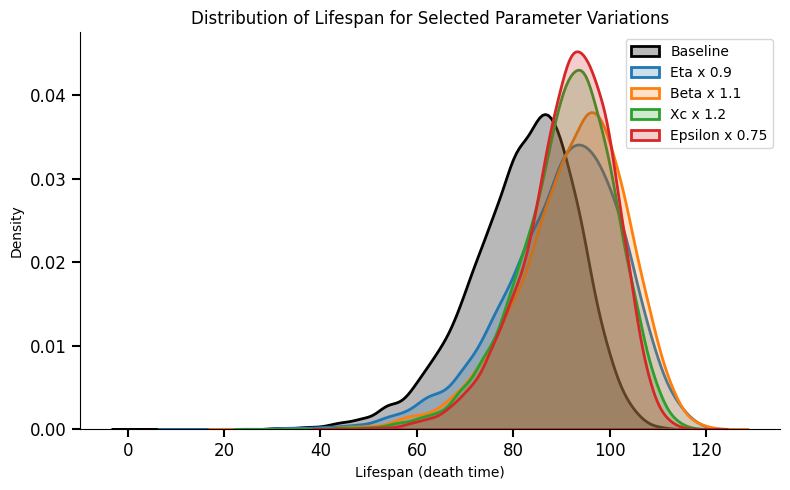

In [16]:
# For reproducibility
np.random.seed(42)

import matplotlib.pyplot as plt
import seaborn as sns

# Load baseline parameters and setup
base_dict = utils.load_baseline_human_params_dict()
n = int(1e4)

# Helper to copy and expand parameter dict as arrays
def prepare_params_dict(base_dict, n, param=None, factor=1.0):
    dict_copy = base_dict.copy()
    for key in dict_copy.keys():
        if isinstance(dict_copy[key], (np.ndarray, list)) and len(dict_copy[key]) == 1:
            dict_copy[key] = np.repeat(dict_copy[key], n)
        elif np.isscalar(dict_copy[key]):
            dict_copy[key] = np.repeat(np.array([dict_copy[key]]), n)
    if param:
        dict_copy[param] = factor * dict_copy[param]
    return dict_copy

# Run baseline simulation (for color/legend reference)
baseline_dict = prepare_params_dict(base_dict, n)
baseline_sim = utils.create_sr_simulation(params_dict=baseline_dict, n=n, parallel=False)
baseline_death_times = baseline_sim.death_times
# Remove censored/infinite death times for proper distribution
baseline_death_times = baseline_death_times[np.isfinite(baseline_death_times)]

# Store all runs in a dict for easy plotting
variants = [
    ('eta', 0.9, 'Eta x 0.9', 'tab:blue'),
    ('beta', 1.1, 'Beta x 1.1', 'tab:orange'),
    ('Xc', 1.2, 'Xc x 1.2', 'tab:green'),
    ('epsilon', 0.75, 'Epsilon x 0.75', 'tab:red')
]

lifespans = []
labels = []
colors = []

for param, factor, label, color in variants:
    param_dict = prepare_params_dict(base_dict, n, param, factor)
    sim = utils.create_sr_simulation(params_dict=param_dict, n=n, parallel=False)
    dtimes = sim.death_times
    dtimes = dtimes[np.isfinite(dtimes)]
    lifespans.append(dtimes)
    labels.append(label)
    colors.append(color)

# Add baseline to the plot as well, for comparison
lifespans.insert(0, baseline_death_times)
labels.insert(0, 'Baseline')
colors.insert(0, 'black')

# Plot: Overlay all lifespan distributions
plt.figure(figsize=(8, 5))

for arr, label, color in zip(lifespans, labels, colors):
    sns.kdeplot(arr, label=label, color=color, fill=True, alpha=0.23 if color!='black' else 0.28, linewidth=2)

plt.xlabel('Lifespan (death time)')
plt.ylabel('Density')
plt.title('Distribution of Lifespan for Selected Parameter Variations')
plt.legend()
plt.tight_layout()
plt.show()


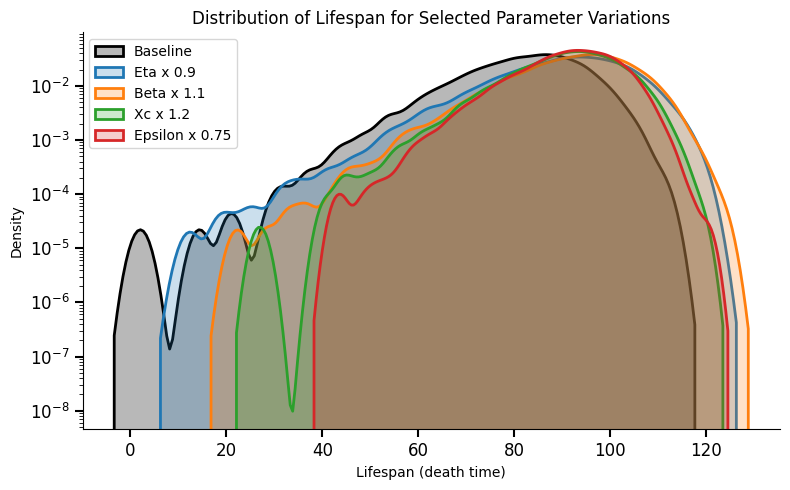

In [17]:
# Plot: Overlay all lifespan distributions
plt.figure(figsize=(8, 5))

for arr, label, color in zip(lifespans, labels, colors):
    sns.kdeplot(arr, label=label, color=color, fill=True, alpha=0.23 if color!='black' else 0.28, linewidth=2)

plt.xlabel('Lifespan (death time)')
plt.ylabel('Density')
plt.title('Distribution of Lifespan for Selected Parameter Variations')
plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.show()
